# Ejercicio 8 — Prueba del mejor modelo con señas propias

Fotos reales de señas ASL hechas a mano por los integrantes del grupo: **Daniel** (K, L, M, N, O),
**Dulce** (A, B, C, D, E) y **Javier** (F, G, H, I, U) — 15 fotos en total, 5 letras distintas por
integrante, en `data/raw/fotos_propias/`, nombradas como `<persona>_<letra>.jpeg`.

In [1]:
import json
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

MODELS_DIR = Path("../models")
PROCESSED_DIR = Path("../../data/processed/asl_alphabet")
FOTOS_DIR = Path("../../data/raw/fotos_propias")
FIGURAS_DIR = Path("../../reports/figuras")

with open(PROCESSED_DIR / "clases.json") as f:
    clase_a_indice = json.load(f)
indice_a_clase = {v: k for k, v in clase_a_indice.items()}

with open(MODELS_DIR / "mejor_modelo_info.json") as f:
    info_modelo = json.load(f)
print("Mejor modelo (entrenamiento):", info_modelo)

es_rf = info_modelo["categoria"].startswith("Clásico")
if es_rf:
    modelo = joblib.load(MODELS_DIR / "mejor_modelo_rf.joblib")
else:
    modelo = tf.keras.models.load_model(MODELS_DIR / "mejor_modelo.keras")

Mejor modelo (entrenamiento): {'nombre': 'CNN_B_profunda_do0.3', 'categoria': 'CNN', 'test_acc': 0.9659003831417624, 'test_f1_macro': 0.9657775688076542}


In [2]:
def preprocesar(ruta: str, size: int = 64) -> np.ndarray:
    with Image.open(ruta) as im:
        im = im.convert("RGB").resize((size, size), Image.BILINEAR)
        return np.asarray(im, dtype=np.float32) / 255.0


def extraer_hog(X, win=(64, 64), block=(16, 16), block_stride=(8, 8), cell=(8, 8), nbins=9):
    hog = cv2.HOGDescriptor(win, block, block_stride, cell, nbins)
    feats = [hog.compute(cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)).flatten()
              for img in X]
    return np.stack(feats)


fotos = sorted(FOTOS_DIR.glob("*.jpg")) + sorted(FOTOS_DIR.glob("*.jpeg")) + sorted(FOTOS_DIR.glob("*.png"))
if not fotos:
    raise FileNotFoundError(
        f"No hay fotos en {FOTOS_DIR}. Agrega al menos 5 fotos (una letra distinta cada una) "
        "nombradas como '<persona>_<letra>.jpg' y vuelve a ejecutar este notebook."
    )
print(f"{len(fotos)} fotos encontradas")

15 fotos encontradas


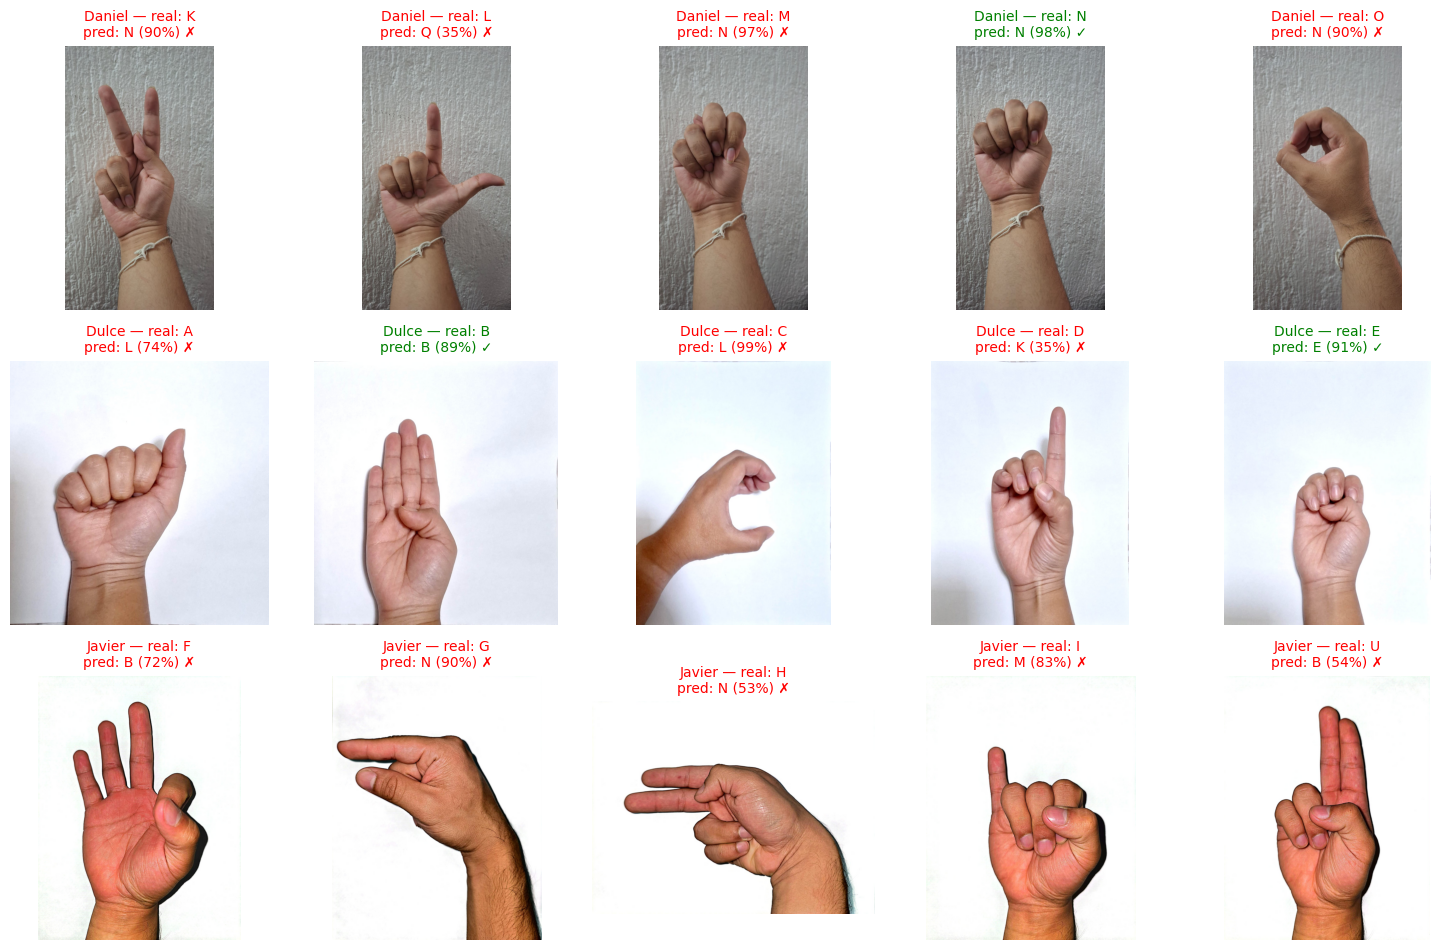

Aciertos totales: 3/15 (20%)
  Daniel: 1/5
  Dulce: 2/5
  Javier: 0/5


In [3]:
X_propias = np.stack([preprocesar(f) for f in fotos])
personas = [f.stem.split("_")[0] for f in fotos]
etiquetas_reales = [f.stem.split("_")[1].upper() for f in fotos]

if es_rf:
    pred_idx = modelo.predict(extraer_hog(X_propias))
    confianza = modelo.predict_proba(extraer_hog(X_propias)).max(axis=1)
else:
    probs = modelo.predict(X_propias, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    confianza = probs.max(axis=1)
pred_clase = [indice_a_clase[i] for i in pred_idx]

n = len(fotos)
personas_unicas = sorted(set(personas))
fig, axes = plt.subplots(len(personas_unicas), 5, figsize=(15, 3.2 * len(personas_unicas)))
for fila_idx, persona in enumerate(personas_unicas):
    idxs = [i for i, p in enumerate(personas) if p == persona]
    for col_idx, i in enumerate(idxs):
        ax = axes[fila_idx, col_idx]
        ax.imshow(Image.open(fotos[i]))
        correcto = "✓" if pred_clase[i] == etiquetas_reales[i] else "✗"
        color = "green" if pred_clase[i] == etiquetas_reales[i] else "red"
        ax.set_title(f"{persona} — real: {etiquetas_reales[i]}\npred: {pred_clase[i]} "
                     f"({confianza[i]:.0%}) {correcto}", color=color, fontsize=10)
        ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURAS_DIR / "asl_ej8_fotos_propias.png", bbox_inches="tight")
plt.show()

aciertos = sum(p == r for p, r in zip(pred_clase, etiquetas_reales))
print(f"Aciertos totales: {aciertos}/{n} ({aciertos / n:.0%})")
for persona in personas_unicas:
    idxs = [i for i, p in enumerate(personas) if p == persona]
    ac_persona = sum(pred_clase[i] == etiquetas_reales[i] for i in idxs)
    print(f"  {persona}: {ac_persona}/{len(idxs)}")

## Discusión

**Resultado: 3/15 aciertos (20%)** — Daniel 1/5, Dulce 2/5, Javier 0/5 — con el mejor modelo
(`CNN_B_profunda_do0.3`), que en el split de prueba propio del dataset (`entrega_final_modelos.ipynb`)
alcanzó **96.6% de accuracy**. La caída de ~77 puntos porcentuales es enorme, y es exactamente la
evidencia empírica que anticipaba la reflexión de accesibilidad del ejercicio 9: el modelo no
generaliza a manos, cámaras, fondos e iluminación distintos a los del dataset de entrenamiento
(**domain shift**), aunque su desempeño *dentro* de la distribución de entrenamiento sea excelente.

**Patrones en los errores:**
- **El modelo está sesgado hacia predecir "N"**: 4 de las 15 fotos (K, M, O de Daniel; G y H de
  Javier) se clasificaron como "N", casi siempre con confianza muy alta (90-98%). Esto sugiere que
  "N" actúa como una especie de "clase por defecto" ante entradas que se alejan de la distribución de
  entrenamiento — probablemente porque la pose de puño cerrado con dedos doblados (común a K, M, O, G
  parcialmente) cae, bajo el color de piel/fondo/iluminación distintos de estas fotos, más cerca de
  la región de del espacio de píxeles que el modelo asocia a N que a la clase correcta.
- **El modelo es confiado incluso cuando se equivoca**: la confianza promedio en los aciertos y en
  los errores es similar (varios errores con >90% de confianza, ej. M→N 97%, C→L 99%). Esto es
  preocupante para un producto real: el modelo no "sabe que no sabe" ante entradas fuera de
  distribución, así que no se le puede pedir a SignBridge que use la confianza del softmax como señal
  de cuándo desconfiar de una predicción sin calibración adicional.
- Los dos aciertos de Dulce (B, E) y el de Daniel (N) corresponden a señas con una forma de mano muy
  distintiva (dedos muy extendidos o muy cerrados) que aparentemente sobrevive mejor al cambio de
  cámara/fondo que señas con diferencias más sutiles en la posición del pulgar (K/M/O, confundibles
  entre sí incluso dentro del propio dataset, ver EDA del avance).

**Conclusión:** el ~96% de accuracy en el split de prueba mide qué tan bien el modelo interpola
dentro de la distribución particular del dataset ASL Alphabet (una persona, una cámara, un fondo fijo)
— no mide qué tan bien reconocería señas de un usuario real de SignBridge. El resultado del ejercicio
8 es la prueba más honesta de las limitaciones de generalización del prototipo, y motiva directamente
las recomendaciones del ejercicio 9 (dataset propio y diverso, normalización vía landmarks de mano en
vez de píxeles crudos, medir desempeño desagregado por subgrupo antes de lanzar a producción).